# 1. Research

This project uses a public store sales dataset containing daily sales data
from 10 stores between January 2022 and December 2023.

Three forecasting approaches were researched:

1. Moving Average – used to smooth short-term fluctuations and identify trends.
2. ARIMA – a statistical time-series forecasting model.
3. Prophet – a forecasting model that can identify trends and seasonal patterns
   and provide uncertainty intervals.

For this project, Prophet was selected because it provides an easy way to model
trend and seasonality and generate forecasts with uncertainty bounds.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

In [2]:
df = pd.read_csv("Downloads/store_sales.csv")
df.head()

,date,store,sales,promo,holiday
0,01/01/2022,1,184.78,0,0
1,02/01/2022,1,192.62,0,0
2,03/01/2022,1,212.68,0,0
3,04/01/2022,1,249.58,1,0
4,05/01/2022,1,223.50,0,0


# Understanding the Data

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7300 non-null   object 
 1   store    7300 non-null   int64  
 2   sales    7300 non-null   float64
 3   promo    7300 non-null   int64  
 4   holiday  7300 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 285.3+ KB


date       0
store      0
sales      0
promo      0
holiday    0
dtype: int64

# Data Cleaning

In [6]:
df['date'] = pd.to_datetime(
    df['date'],
    format='%d/%m/%Y'
)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7300 entries, 0 to 7299
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     7300 non-null   datetime64[ns]
 1   store    7300 non-null   int64         
 2   sales    7300 non-null   float64       
 3   promo    7300 non-null   int64         
 4   holiday  7300 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 285.3 KB


In [8]:
print("Start Date:", df['date'].min())
print("End Date:", df['date'].max())

Start Date: 2022-01-01 00:00:00
End Date: 2023-12-31 00:00:00


In [9]:
print("Number of stores:", df['store'].nunique())

Number of stores: 10


# Aggregate Sales

In [10]:
daily_sales = (
    df.groupby('date')['sales']
    .sum()
    .reset_index()
)

daily_sales.head()

,date,sales
0,2022-01-01,1947.47
1,2022-01-02,1942.29
2,2022-01-03,2099.73
3,2022-01-04,2292.64
4,2022-01-05,2274.62


In [11]:
print("Number of days:", len(daily_sales))
print("Unique dates:", daily_sales['date'].nunique())

Number of days: 730
Unique dates: 730


# Trend Analysis

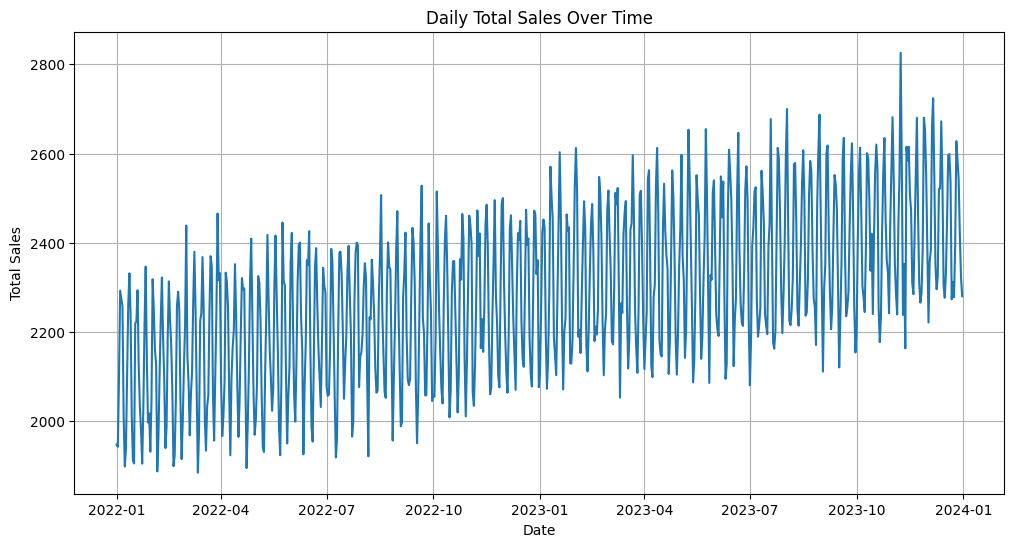

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales']
)

plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

Trend Analysis: The daily total sales show an overall gradual upward trend over the two-year period. However, there are frequent fluctuations in daily sales, indicating possible recurring seasonal patterns. A 30-day moving average will be used next to smooth these short-term variations and better visualize the underlying sales trend.

# 30 Day Moving Average

In [13]:
daily_sales['30_day_MA'] = (
    daily_sales['sales']
    .rolling(window=30)
    .mean()
)

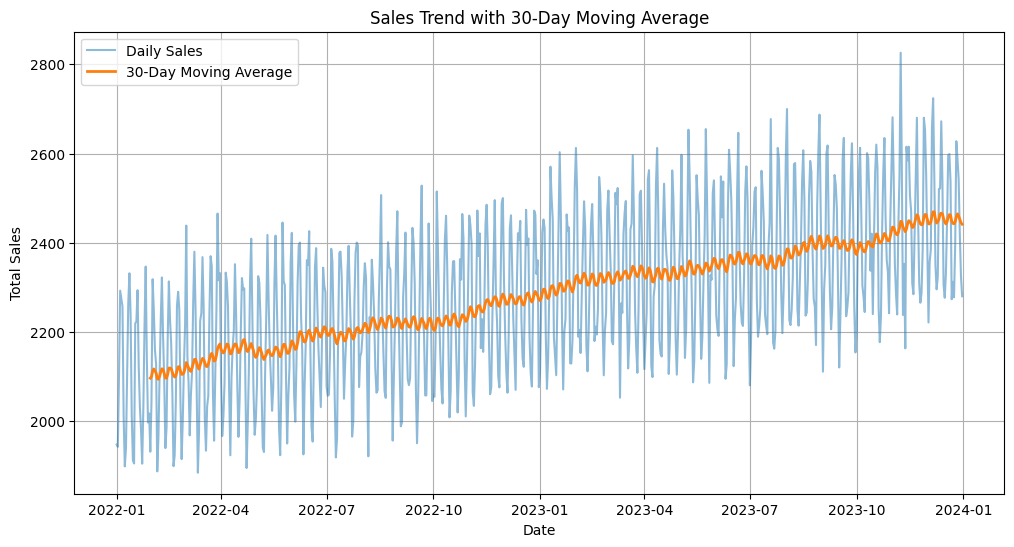

In [14]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_sales['date'],
    daily_sales['sales'],
    label='Daily Sales',
    alpha=0.5
)

plt.plot(
    daily_sales['date'],
    daily_sales['30_day_MA'],
    label='30-Day Moving Average',
    linewidth=2
)

plt.title('Sales Trend with 30-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.legend()
plt.grid(True)

plt.show()

Moving Average Analysis:
The 30-day moving average was used to smooth daily fluctuations in sales and identify the underlying trend. The results show a gradual upward trend in total sales from 2022 to 2023. Although daily sales fluctuate significantly, the moving average indicates that overall business demand has increased over time

# Monthly Trend Analysis

In [15]:
monthly_sales = (
    daily_sales
    .set_index('date')['sales']
    .resample('ME')
    .sum()
    .reset_index()
)

monthly_sales.head()

,date,sales
0,2022-01-31,64933.35
1,2022-02-28,59285.49
2,2022-03-31,67406.14
3,2022-04-30,64375.23
4,2022-05-31,67066.32


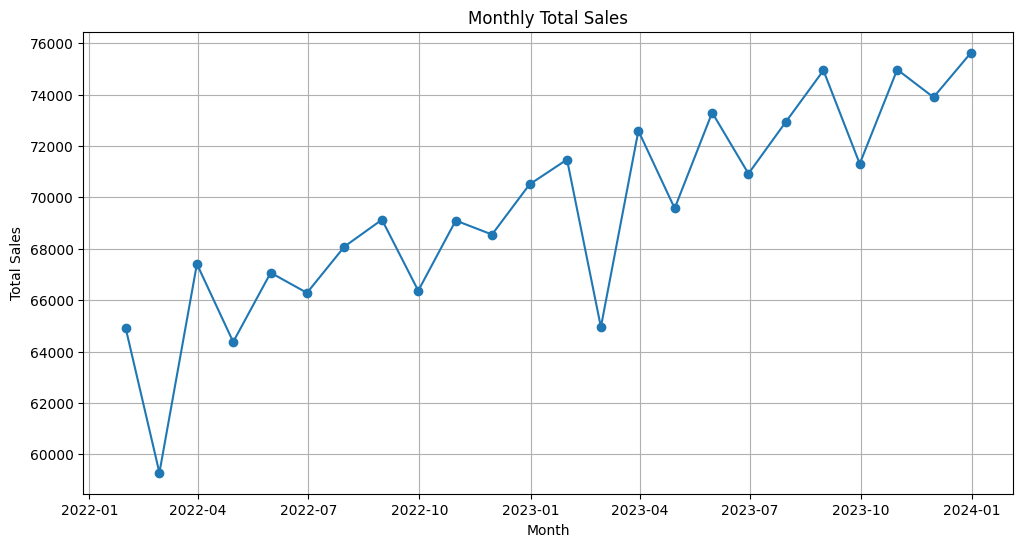

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales['date'],
    monthly_sales['sales'],
    marker='o'
)

plt.title('Monthly Total Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.grid(True)

plt.show()

Monthly sales fluctuate but generally increase over the two-year period, with higher sales toward the end of 2023.

# Average Sales by Month

In [18]:
daily_sales['month'] = daily_sales['date'].dt.month

monthly_pattern = (
    daily_sales.groupby('month')['sales']
    .mean()
)

print(monthly_pattern)

month
1     2200.068548
2     2218.540357
3     2258.024194
4     2232.460667
5     2263.952903
6     2286.744667
7     2274.648226
8     2323.697742
9     2294.536667
10    2323.679032
11    2374.114000
12    2356.941452
Name: sales, dtype: float64


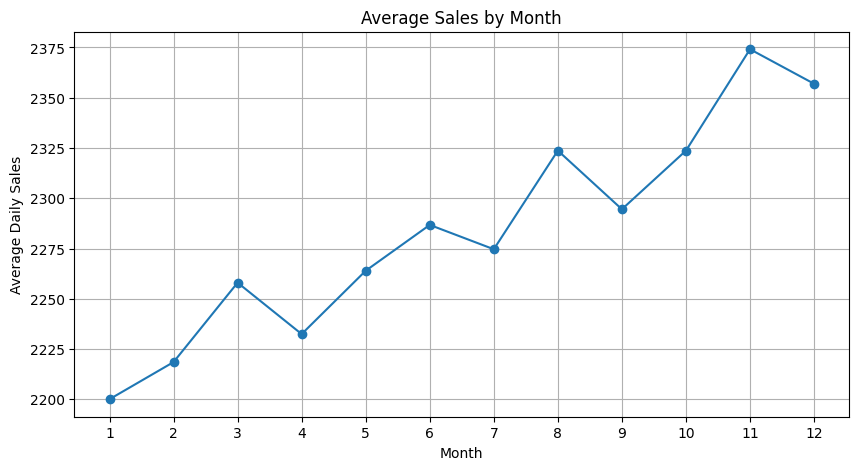

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_pattern.index,
    monthly_pattern.values,
    marker='o'
)

plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Daily Sales')

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

Average sales generally rise throughout the year, with higher sales observed in November and December, suggesting possible yearly seasonality.

# Average Sales by Week

In [20]:
daily_sales['day_of_week'] = daily_sales['date'].dt.day_name()

days = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekly_pattern = (
    daily_sales
    .groupby('day_of_week')['sales']
    .mean()
    .reindex(days)
)

print(weekly_pattern)

day_of_week
Monday       2278.064135
Tuesday      2445.557885
Wednesday    2480.470385
Thursday     2371.863942
Friday       2192.087019
Saturday     2094.624190
Sunday       2131.050667
Name: sales, dtype: float64


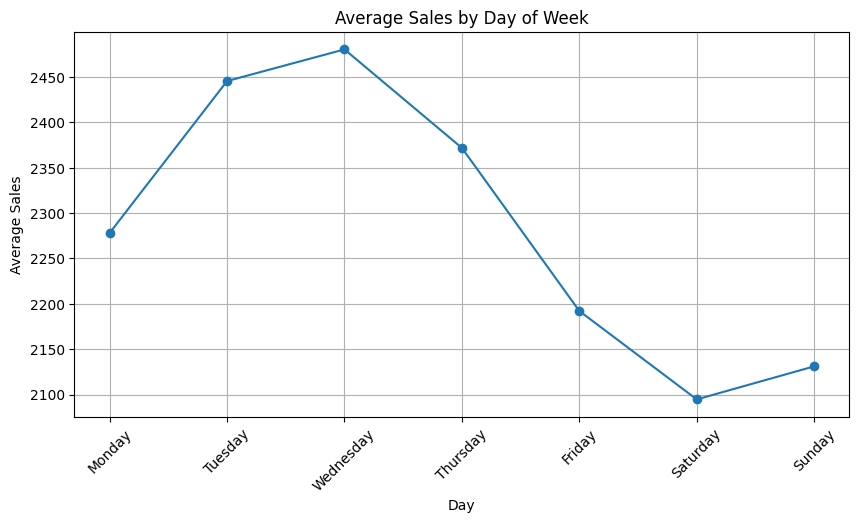

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_pattern.index,
    weekly_pattern.values,
    marker='o'
)

plt.title('Average Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Average Sales')

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

Sales vary across the week, with the highest average sales around Wednesday and lower sales toward the weekend, showing a clear weekly seasonal pattern.

# Prophet Model

In [22]:
prophet_df = daily_sales[['date', 'sales']].copy()

prophet_df = prophet_df.rename(
    columns={
        'date': 'ds',
        'sales': 'y'
    }
)

prophet_df.head()

,ds,y
0,2022-01-01,1947.47
1,2022-01-02,1942.29
2,2022-01-03,2099.73
3,2022-01-04,2292.64
4,2022-01-05,2274.62


In [23]:
train = prophet_df.iloc[:-90].copy()
test = prophet_df.iloc[-90:].copy()

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 640
Testing data: 90


In [24]:
print("Training period:", train['ds'].min(), "to", train['ds'].max())
print("Testing period:", test['ds'].min(), "to", test['ds'].max())

Training period: 2022-01-01 00:00:00 to 2023-10-02 00:00:00
Testing period: 2023-10-03 00:00:00 to 2023-12-31 00:00:00


# Create and Train the Model

In [25]:
from prophet import Prophet

model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.
21:37:57 - cmdstanpy - INFO - Chain [1] start processing
21:37:58 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
future = model.make_future_dataframe(
    periods=90,
    freq='D'
)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
725,2023-12-27,2658.954591,2583.899784,2730.945084
726,2023-12-28,2553.670344,2485.352773,2622.117933
727,2023-12-29,2375.149867,2302.862268,2447.667587
728,2023-12-30,2271.473174,2202.952763,2342.014257
729,2023-12-31,2316.888018,2240.638369,2387.792826


In [27]:
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

21:39:31 - cmdstanpy - INFO - Chain [1] start processing
21:39:31 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
future = model.make_future_dataframe(
    periods=90,
    freq='D'
)

forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
725,2023-12-27,2628.740189,2560.553987,2700.645217
726,2023-12-28,2523.205655,2457.451511,2592.684348
727,2023-12-29,2344.485125,2273.209210,2416.849597
728,2023-12-30,2240.616021,2175.730295,2313.398954
729,2023-12-31,2285.887889,2211.018597,2357.422784


# Backtesting (Actual vs Predicted)

In [29]:
# Get predictions for the test period
test_forecast = forecast[
    forecast['ds'].isin(test['ds'])
][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Merge actual sales with predictions
comparison = test.merge(
    test_forecast,
    on='ds',
    how='left'
)

comparison.head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2023-10-03,2553.68,2567.057602,2495.533032,2642.388187
1,2023-10-04,2612.94,2597.198482,2527.687732,2664.547697
2,2023-10-05,2472.00,2491.663948,2416.906495,2567.552242
3,2023-10-06,2304.03,2312.943418,2243.204160,2375.148990
4,2023-10-07,2278.27,2209.074315,2132.009178,2282.856818


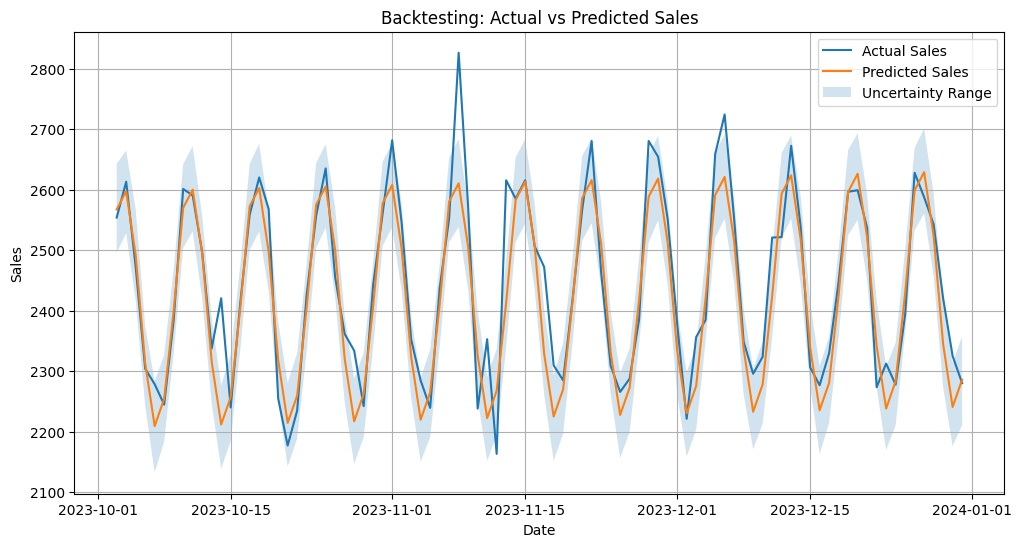

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison['ds'],
    comparison['y'],
    label='Actual Sales'
)

plt.plot(
    comparison['ds'],
    comparison['yhat'],
    label='Predicted Sales'
)

plt.fill_between(
    comparison['ds'],
    comparison['yhat_lower'],
    comparison['yhat_upper'],
    alpha=0.2,
    label='Uncertainty Range'
)

plt.title('Backtesting: Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.grid(True)

plt.show()

## Backtesting Analysis:

The predicted sales generally follow the same weekly pattern as the actual sales. While the model does not capture every sudden spike or drop perfectly, it successfully identifies the overall trend and recurring weekly seasonality. The uncertainty range shows the possible range within which future sales may fall.

# Calculate MAPE

In [31]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    comparison['y'],
    comparison['yhat']
) * 100

print(f"MAPE: {mape:.2f}%")

MAPE: 1.88%


## Model Accuracy:

The Prophet model achieved a Mean Absolute Percentage Error (MAPE) of 1.88% on the held-out 90-day test dataset. This indicates that the model performed well in predicting sales and successfully captured the main weekly patterns in the data.

# Final Forward Forecast

In [32]:
final_model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(prophet_df)

21:44:14 - cmdstanpy - INFO - Chain [1] start processing
21:44:14 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
future_dates = final_model.make_future_dataframe(
    periods=90,
    freq='D'
)

final_forecast = final_model.predict(future_dates)

final_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
815,2024-03-26,2666.330454,2594.209693,2740.151116
816,2024-03-27,2701.262209,2627.515809,2779.915927
817,2024-03-28,2592.672565,2528.263722,2664.348406
818,2024-03-29,2412.910893,2341.974454,2485.933200
819,2024-03-30,2317.218924,2244.598178,2390.123395


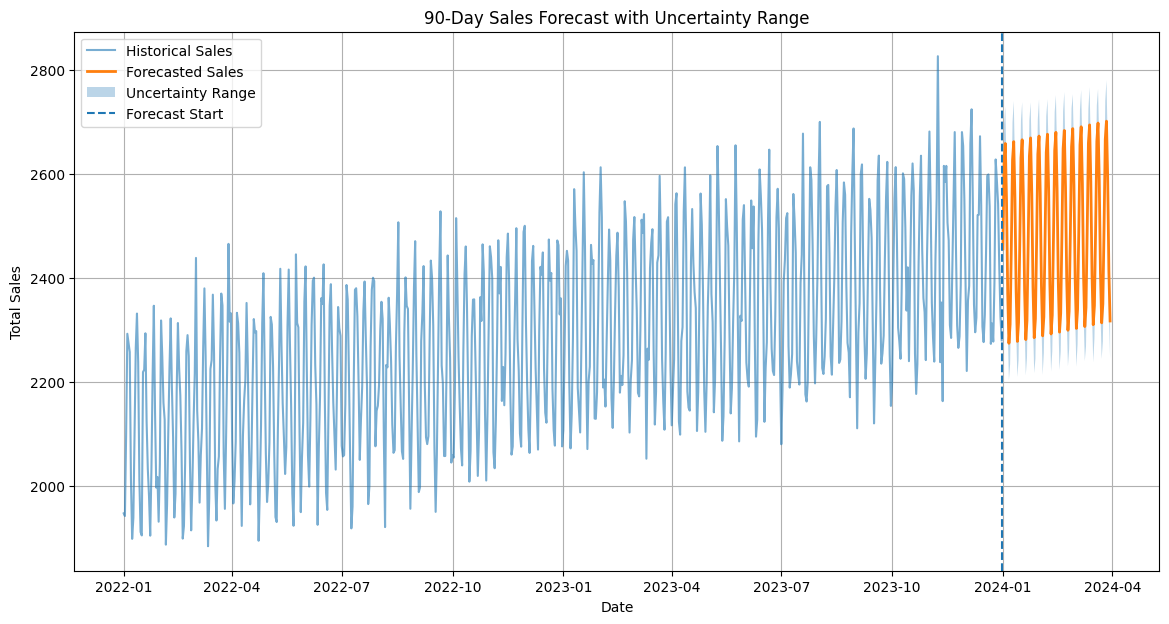

In [34]:
plt.figure(figsize=(14, 7))

# Historical sales
plt.plot(
    prophet_df['ds'],
    prophet_df['y'],
    label='Historical Sales',
    alpha=0.6
)

# Forecasted sales (future only)
future_forecast = final_forecast[
    final_forecast['ds'] > prophet_df['ds'].max()
]

plt.plot(
    future_forecast['ds'],
    future_forecast['yhat'],
    label='Forecasted Sales',
    linewidth=2
)

# Uncertainty range
plt.fill_between(
    future_forecast['ds'],
    future_forecast['yhat_lower'],
    future_forecast['yhat_upper'],
    alpha=0.3,
    label='Uncertainty Range'
)

# Separate historical and forecast periods
plt.axvline(
    prophet_df['ds'].max(),
    linestyle='--',
    label='Forecast Start'
)

plt.title('90-Day Sales Forecast with Uncertainty Range')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.legend()
plt.grid(True)

plt.show()

## 90-Day Sales Forecast: 

The Prophet model forecasts sales for the next 90 days based on historical trends and weekly seasonal patterns. The shaded uncertainty range represents the possible variation around the predicted sales values.

# Model Evaluation & Improvements

## Model Evaluation

The Prophet forecasting model achieved a MAPE of 1.88% on the 90-day held-out test data. This indicates that the models predictions were generally close to the actual sales values. The backtesting chart also shows that the model successfully captured the repeating weekly sales pattern.

## Model Limitations

The dataset contains only two years of historical data, which may limit the model's ability to identify long-term yearly patterns.
The model does not include external factors such as promotions, holidays, competitor activity, or economic conditions.
Unexpected events or sudden changes in customer behavior may reduce forecast accuracy.

## Improvements Made & Future Improvements

The model was improved by disabling yearly seasonality because the dataset contains only approximately two years of historical data. Weekly seasonality was retained because the exploratory analysis showed a clear weekly sales pattern.

Future versions could include additional features such as promotions, holidays, store-specific forecasting, and external economic factors. More historical data could also improve long-term forecasting accuracy.